In [ ]:
# | default_exp curator

In [ ]:
#| export
from fasthtml.common import *
from fasthtml.jupyter import *
from monsterui.all import *
from fastcore.script import call_parse
from iomeval.pipeline import Report, load_report
from iomeval.extract import extract_sections
from iomeval.core import n_tokens
from pathlib import Path
from mistocr.core import read_pgs
from mistocr.refine import apply_hdg_fixes
from starlette.requests import Request
import re

In [ ]:
#| export
esc_behaviour= Script("""
document.addEventListener('keydown', e => {
    if (e.key === 'Escape') htmx.ajax('GET', '/editor-reset', {target: '#editor', swap: 'innerHTML'});
});
""")

In [ ]:
#| export
app, rt = fast_app(
    title='IOM Curator',
    hdrs=Theme.slate.headers(mode='light', radii='small') + [esc_behaviour],
    live=True
)

In [ ]:
#| export
BASE_PATH = 'files/test'

### Helper functions

In [ ]:
#| export
def get_reports(base_path=BASE_PATH, status=None):
    results_dir = Path(base_path)/'results'
    reports = [load_report(p.stem, base_path) for p in results_dir.glob('*.json')]
    if status and status != 'all':
        reports = [r for r in reports if r.curation_status == status]
    return reports

In [ ]:
#| export
def fmt_status(status): return status.replace('_', ' ').title()

In [ ]:
#| export
def count_selected_tokens(r, selected_hdgs):
    if not selected_hdgs: return 0
    md = read_pgs(r.md_path)
    return n_tokens(extract_sections(md, selected_headings=selected_hdgs))

In [ ]:
#| export
def get_progress(reports):
    done = sum(1 for r in reports if r.curation_status == 'sections_selected')
    return done, len(reports)

### Components

In [ ]:
#| export
def get_headings(md_path):
    md = read_pgs(md_path)
    return re.findall(r'^#+\s+.*$', md, re.MULTILINE)

In [ ]:
#| export
status_colors = dict(pending='amber', headings_reviewed='blue', sections_selected='emerald')

In [ ]:
#| export
def ReportCard(r:Report, selected:bool=False, status:str='all'):
    title = r.ev.meta.get('Title', 'Untitled')
    title_short = title[:50] + '...' if len(title) > 50 else title
    year = r.ev.meta.get('Year', 'n/a')
    status_cls = {
        'pending': 'bg-red-500 text-white',
        'headings_reviewed': 'bg-blue-500 text-white', 
        'sections_selected': 'bg-emerald-500 text-white'
    }
    highlight = 'ring-1 ring-primary' if selected else ''
    return Card(
        DivFullySpaced(
            Div(
                P(title_short, title=title, cls=TextPresets.bold_sm + ' uppercase truncate'),
                DivLAligned(
                    Span(fmt_status(r.curation_status), cls=f'uk-label {status_cls[r.curation_status]} ' + TextT.xs),
                    Small(f"{year}", cls=TextPresets.muted_sm),
                    Small(f'{r.id[:4]}...', cls=TextPresets.muted_sm),
                    A("PDF", href=r.pdf_url, target='_blank', cls=TextT.sm + ' ' + AT.primary),
                    cls='gap-2'
                ),
                cls='space-y-0.5'
            ),
            Button(
                "Curate", 
                hx_get=f'/report/{r.id}?status={status}', 
                hx_target='#editor', 
                cls='h-6 px-2 ' + TextT.xs + ButtonT.primary)
        ),
        cls=f'mb-2 {highlight}', body_cls='p-3'
    )

In [ ]:
#| export
def StatusSteps(status):
    steps = ['pending', 'headings_reviewed', 'sections_selected']
    labels = ['Clean Headings', 'Select Sections']
    current_idx = steps.index(status)
    
    return Steps(*[
        LiStep(label, cls=StepT.success if i < current_idx else StepT.neutral)
        for i, label in enumerate(labels)
    ], cls='mb-2 w-full')

In [ ]:
#| export
def HeadingsEditor(r:Report):
    headings = get_headings(r.md_path)
    title = r.ev.meta.get('Title', 'Untitled')
    return Div(
        H5(title, cls='font-bold mb-2 text-sm'),
        StatusSteps(r.curation_status),
        Form(
            Div(*[
                Input(value=h, name=f'heading_{i}', cls='mb-1 w-full font-mono text-xs')
                for i, h in enumerate(headings)
            ], 
            cls='space-y-1 max-h-[60vh] overflow-y-auto px-2 py-2 bg-slate-50 rounded border border-slate-200'
            ),
            Hidden(name='report_id', value=r.id),
            DivCentered(Button("Save Headings", type='submit', cls=ButtonT.primary), cls='w-full'),
            hx_post=f'/report/{r.id}/save-headings',
            hx_target='#editor'
        )
    )

In [ ]:
#| export
def token_display(tokens, budget=15000):
    color = 'green' if tokens < budget * 0.8 else 'amber' if tokens < budget else 'red'
    return Span(
        Strong(f"{tokens:,}"), " tokens",
        id='token-count', 
        cls=f'ml-4 text-sm text-{color}-600 w-32 inline-block'
    )

In [ ]:
#| export
def SectionsSelector(r:Report):
    headings = get_headings(r.md_path)
    title = r.ev.meta.get('Title', 'Untitled')
    return Div(
        H5(title, cls='font-bold mb-2 text-sm'),
        StatusSteps(r.curation_status),
        Form(
            Div(
                Table(
                    Tbody(*[
                        Tr(
                            Td(
                                CheckboxX(name=f'hdg_{i}', checked=(h in r.selected_headings)), 
                                cls='w-8 !py-1'),
                            Td(h, cls='font-mono text-xs !py-1'),
                            cls='border-b'
                        )
                        for i, h in enumerate(headings)
                    ]),
                    cls='w-full uk-table-middle'
                ),
                cls='max-h-[60vh] overflow-y-auto bg-slate-50 rounded border border-slate-200'
            ),
            DivCentered(
                DivLAligned(
                    Button(
                        "Save Selection", 
                        type='submit', 
                        cls=ButtonT.primary,
                        hx_swap='innerHTML',
                        hx_post=f'/report/{r.id}/save-sections',
                        hx_target='#editor'
                        ),
                        token_display(count_selected_tokens(r, r.selected_headings))
                ),
                cls='mt-2'
            ),
            hx_post=f'/report/{r.id}/token-count',
            hx_trigger='change from:input[type=checkbox]',
            hx_target='#token-count',
            hx_swap='outerHTML',
        ),
        Button("← Back to Headings", hx_post=f'/report/{r.id}/reset-to-pending', hx_target='#editor', hx_swap='innerHTML', cls='mt-2')
    )

In [ ]:
#| export
def ProgressBar(reports, oob=False):
    done, total = get_progress(reports)
    pct = int(done / total * 100) if total else 0
    return Div(
        DivLAligned(
            Progress(value=pct, max=100, cls='mb-0'),
            P(f"{done}/{total} complete", cls=TextT.sm + 'w-48'),
            cls='gap-2'
        ),
        id='progress-bar',
        hx_swap_oob='true' if oob else None
    )

In [ ]:
#| export
def StatusFilter(current='all'):
    statuses = [('all', 'All'), ('pending', 'Pending'), ('headings_reviewed', 'Reviewed'), ('sections_selected', 'Selected')]
    return TabContainer(*[
        Li(A(label, hx_get=f'/filter?status={key}', hx_target='#report-list', hx_swap='innerHTML'),
           cls='uk-active' if key == current else '')
        for key, label in statuses
    ], alt=True, cls=TextT.sm)

### Routes

In [ ]:
#| export
@rt('/')
def get():
    reports = get_reports()
    return Container(
        H2("IOMEVAL | Reports Curator", cls="text-2xl font-bold mb-6"),
        Grid(
            Card(
                DivFullySpaced(
                    H4("Reports"), 
                    Div(ProgressBar(reports), cls='w-4/5'),  # or w-64, w-56 etc.
                    cls='items-center'
                ),
                DivCentered(Div(StatusFilter(), id='status-filter'), cls='w-2/3 mx-auto'),
                Div(*[ReportCard(r) for r in reports], id='report-list', cls='overflow-y-auto max-h-[80vh]')),
            Card(
                H4("Editor"), 
                Div(id='editor', cls='p-2')(
                    DivCentered(P('Click "Curate" to select a report', cls="font-normal"), cls='h-40')
                ), 
                cls="h-full"
            ),
            cols=2, gap=4
        ),
        cls="p-4"
    )

In [ ]:
#| export
@rt('/report/{id}')
def get(id:str, status:str='all'):
    r = load_report(id, BASE_PATH)
    reports = get_reports(status=status)
    
    editor = HeadingsEditor(r) if r.curation_status == 'pending' else SectionsSelector(r)
    
    return (
        Div(*[ReportCard(rp, selected=(rp.id == id), status=status) for rp in reports], 
            id='report-list', hx_swap_oob='true'),
        editor
    )

In [ ]:
#| export
@rt('/report/{id}/save-headings')
async def post(id:str, req:Request):
    form = await req.form()
    r = load_report(id, BASE_PATH)
    original_headings = get_headings(r.md_path)
    
    # Build lookup table: {original: edited}
    lut_fixes = {}
    for i, orig in enumerate(original_headings):
        edited = form.get(f'heading_{i}', orig)
        if edited != orig: lut_fixes[orig] = edited
    
    #print("Lookup table (changes only):")
    for old, new in lut_fixes.items():
        print(f"  '{old}' → '{new}'")
    
    # Apply fixes to each page if there are changes
    if lut_fixes:
        for pg_path in sorted(r.md_path.glob('page_*.md')):
            content = pg_path.read_text()
            fixed = apply_hdg_fixes(content, lut_fixes)
            pg_path.write_text(fixed)
    
    # Update status and save
    r.curation_status = 'headings_reviewed'
    r.save()
    
    # Refresh both panels
    reports = get_reports()
    return (
        Div(*[ReportCard(rp, selected=(rp.id == id)) for rp in reports], id='report-list', hx_swap_oob='true'),
        SectionsSelector(r)  # Next step UI
    )

    

In [ ]:
#| export
@rt('/report/{id}/reset-to-pending')
def post(id:str):
    r = load_report(id, BASE_PATH)
    r.curation_status = 'pending'
    r.save()
    
    reports = get_reports()
    return (
        Div(*[ReportCard(rp, selected=(rp.id == id)) for rp in reports], id='report-list', hx_swap_oob='true'),
        HeadingsEditor(r),
        ProgressBar(reports, oob=True)
    )

    

In [ ]:
#| export
@rt('/report/{id}/token-count')
async def post(id:str, req:Request):
    form = await req.form()
    r = load_report(id, BASE_PATH)
    
    selected = [int(k.split('_')[1]) for k in form.keys() if k.startswith('hdg_')]
    headings = get_headings(r.md_path)
    selected_hdgs = [headings[i] for i in selected]
    print(selected_hdgs)
    
    tokens = count_selected_tokens(r, selected_hdgs)

    return token_display(tokens)

In [ ]:
#| export
@rt('/report/{id}/save-sections')
async def post(id:str, req:Request):
    form = await req.form()
    r = load_report(id, BASE_PATH)
    headings = get_headings(r.md_path)
    
    selected = [int(k.split('_')[1]) for k in form.keys() if k.startswith('hdg_')]
    r.selected_headings = [headings[i] for i in selected]
    r.curation_status = 'sections_selected'
    r.save()
    
    reports = get_reports()

    return (
        Div(*[ReportCard(rp) for rp in reports], id='report-list', hx_swap_oob='true'),
        DivCentered(P('Click "Curate" to select a report', cls="font-normal"), cls='h-40'),
        ProgressBar(reports, oob=True)
    )

In [ ]:
#| export
@rt('/filter')
def get(status:str='all'):
    reports = get_reports(status=status)
    return (
        Div(*[ReportCard(r, status=status) for r in reports], id='report-list'),
        Div(StatusFilter(current=status), id='status-filter', hx_swap_oob='true'),
        Div(
            DivCentered(P('Click "Curate" to select a report', cls="font-normal"), cls='h-40'),
            id='editor', cls='p-2', hx_swap_oob='true'
        )
    )

In [ ]:
#| export
@rt('/editor-reset')
def get():
    reports = get_reports()
    return (
        Div(*[ReportCard(r) for r in reports], id='report-list', hx_swap_oob='true'),
        DivCentered(P('Click "Curate" to select a report', cls="font-normal"), cls='h-40')
    )

In [ ]:
#| export
# | export
@call_parse
def main(host:str='0.0.0.0', port:int=5001):
    "Run the curator app"
    serve(host=host, port=port)

if __name__ == "__main__": main()

### Server

In [ ]:
# Dev cell (not exported)
srv = JupyUvi(app)

['## 1. Introduction ... page 4', '## 2. Background of the JI-HoA ... page 5', '## 3. Methodology ... page 8']


['## 1. Introduction ... page 4', '## 2. Background of the JI-HoA ... page 5', '## 3. Methodology ... page 8', '## 5. Conclusions and Recommendations ... page 27']


['## 1. Introduction ... page 4', '## 2. Background of the JI-HoA ... page 5', '## 3. Methodology ... page 8', '## 4. Findings ... page 10', '## 5. Conclusions and Recommendations ... page 27']


['## 1. Introduction ... page 4', '## 2. Background of the JI-HoA ... page 5', '## 3. Methodology ... page 8', '## 5. Conclusions and Recommendations ... page 27']


['## 1. Introduction ... page 4', '## 2. Background of the JI-HoA ... page 5', '## 3. Methodology ... page 8', '### 4.3. Effectiveness ... page 16', '## 5. Conclusions and Recommendations ... page 27']


In [ ]:
srv.stop()

I think we lost the report id in the Report card in the dev process:

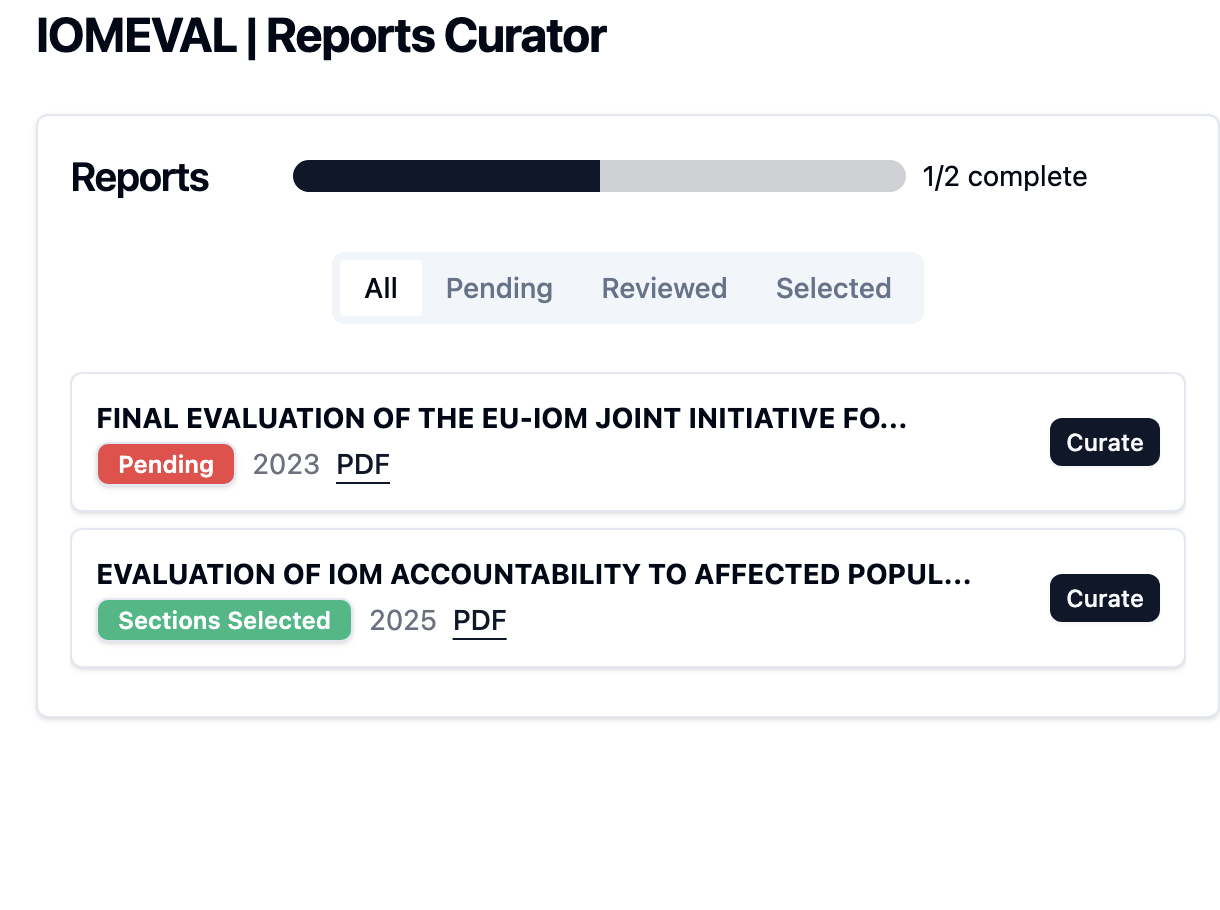

Let's put it back at the right of the year

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Looking at `ReportCard`, you'll want to add the ID in the `DivLAligned` after the year. Add this after the `Small(f"{year}", ...)` line:

```python
Small(r.id, cls=TextPresets.muted_sm),
```

So that section becomes:

```python
DivLAligned(
    Span(fmt_status(r.curation_status), cls=f'uk-label {status_cls[r.curation_status]} ' + TextT.xs),
    Small(f"{year}", cls=TextPresets.muted_sm),
    Small(r.id, cls=TextPresets.muted_sm),
    A("PDF", href=r.pdf_url, target='_blank', cls=TextT.sm + ' ' + AT.primary),
    cls='gap-2'
),
```

And I want it truncated (first four digits should be enough)

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠

```python
Small(r.id[:4], cls=TextPresets.muted_sm),
```